In [93]:
import scipy.io as sio
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from pysptools.abundance_maps.amaps import FCLS
from sklearn import linear_model
import warnings
from sklearn.exceptions import ConvergenceWarning
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score


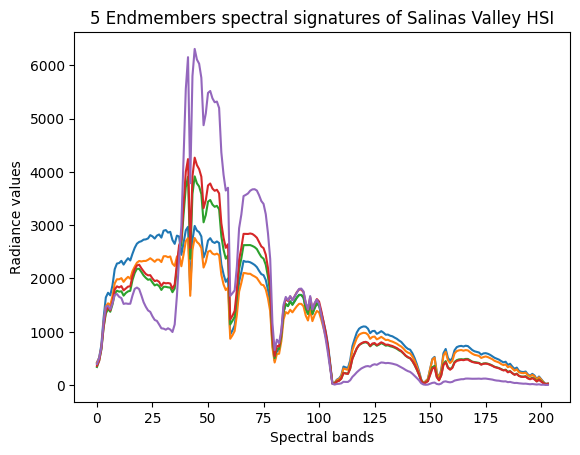

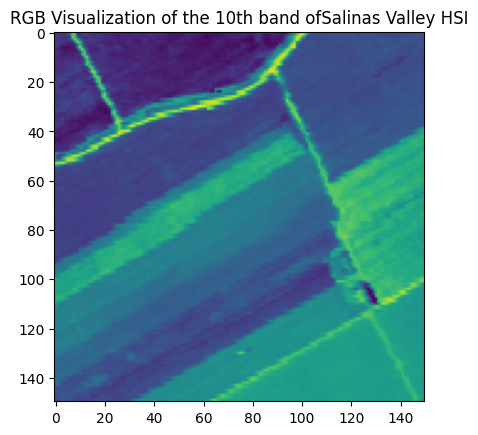

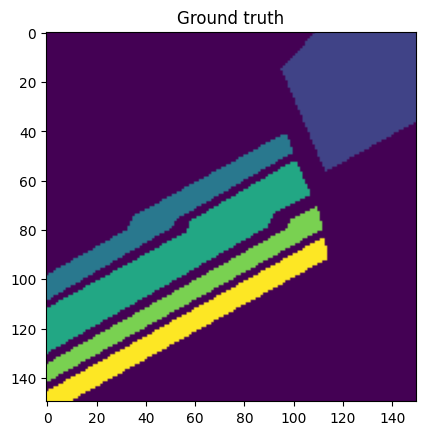

In [94]:
Salinas = sio.loadmat('Salinas_cube.mat')
HSI = Salinas['Salinas_cube'] #Salinas HSI : 150x150x204
Endmembers = sio.loadmat('Salinas_endmembers.mat') # Endmember's matrix: 204x5
endmembers = Endmembers['Salinas_endmembers']

ground_truth=sio.loadmat('Salinas_ground_truth.mat')
labels = ground_truth['salinas_gt']

fig = plt.figure()
plt.plot(endmembers)
plt.ylabel('Radiance values')
plt.xlabel('Spectral bands')
plt.title('5 Endmembers spectral signatures of Salinas Valley HSI')
plt.show()

fig = plt.figure()
plt.imshow(HSI[:,:,10])
plt.title('RGB Visualization of the 10th band ofSalinas Valley HSI')
plt.show()


fig = plt.figure()
plt.imshow(labels)
plt.title('Ground truth')
plt.show()

# For the non-negative least squares  unmixing algorithm  you can use the nnls function, see the following link:
#https://docs.scipy.org/doc/scipy-0.18.1/reference/generated/scipy.optimize.nnls.html#scipy.optimize.nnls
# ..............
#
#..................

# Part 1 (spectral unmixing)

## Spectral Unmixing – Helper Functions

In the linear spectral mixing model, each pixel spectrum can be written as:

### y=Xθ+η

where **y** is the pixel spectral signature, **X** contains the endmember spectra, and **θ** is the abundance vector.  
The following helper functions are used to visualize abundance maps, compute reconstruction error, and validate the results.

In [95]:
# Assign variables for easier reference
y = HSI          # Hyperspectral cube
X = endmembers   # Endmember spectral signatures

### Abundance Map Visualization

After estimating the abundance vectors, we visualize the spatial distribution of each endmember.  
The function below plots the abundance maps of the five materials in the scene.

In [96]:
def plot_endmembers(theta_maps):
    """
    Display the abundance maps of the 5 endmembers.
    Each subplot corresponds to one material.
    """

    # Create a row with 5 plots (one for each endmember)
    fig, ax = plt.subplots(1, 5, figsize=(25, 5))

    # Names of the materials
    materials = ['Broccoli', 'Lettuce 1', 'Lettuce 2', 'Lettuce 3', 'Lettuce 4']

    for idx in range(5):

        # Extract abundance map for the current endmember
        abundance_img = theta_maps[:, :, idx]

        # Display abundance
        im = ax[idx].imshow(abundance_img, cmap='viridis')

        ax[idx].set_title(materials[idx], fontsize=14)
        ax[idx].set_xlabel(f'Endmember {idx+1}')

        # Add color scale
        fig.colorbar(im, ax=ax[idx], fraction=0.046, pad=0.04)

    # Global title
    fig.suptitle('Abundance Maps for 5 Endmembers', fontsize=20)

    fig.tight_layout()
    plt.show()


### Reconstruction Error

To evaluate the spectral unmixing results, we compute the reconstruction error:

### ∥yi​−Xθi​∥^2

The average error is calculated over all pixels with non-zero ground truth labels.

In [97]:
def r_error(theta_maps):
    """
    Compute the reconstruction error for all pixels that have
    non-zero ground truth labels.
    """

    total_error = 0
    valid_pixels = 0

    rows, cols = labels.shape

    for i in range(rows):
        for j in range(cols):

            # Only evaluate pixels with valid class labels
            if labels[i, j] != 0:

                # Reshape abundance vector
                theta_pixel = theta_maps[i, j, :].reshape(5, 1)

                # Reconstruct spectral signature
                y_hat = np.dot(X, theta_pixel).flatten()

                # Compute squared reconstruction error
                err = np.linalg.norm(y[i, j, :] - y_hat) ** 2

                total_error += err
                valid_pixels += 1

    # Mean reconstruction error
    mean_error = total_error / valid_pixels

    print(f"The reconstruction error is: {mean_error:.4f}")

### Validation Check

This function verifies that spectral unmixing was applied only to pixels with non-zero labels by comparing the number of valid pixels in the label map with those in the abundance maps.

In [98]:
def compare_tables(label_table, theta_maps):
    """
    Check whether the number of pixels with non-zero abundance
    vectors matches the number of non-zero labels.
    """

    # Count valid labeled pixels
    label_count = 0
    for row in label_table:
        for value in row:
            if value != 0:
                label_count += 1

    # Count pixels that have at least one non-zero abundance value
    theta_count = 0
    for i in range(150):
        for j in range(150):

            if np.count_nonzero(theta_maps[i, j, :]) > 0:
                theta_count += 1

    # Compare the two counts
    if label_count == theta_count:
        print("Check passed! Non-zero pixels match.")
    else:
        print(f"Non-zero elements in labels table: {label_count}")
        print(f"Non-zero elements in abundance table: {theta_count}")

### (a) Least Squares

In [99]:
# Function that computes the Least Squares abundance vector
def compute_ls_solution(X, y_pixel):
    """
    Compute the Least Squares (LS) solution for the abundance vector.
    
    Parameters
    ----------
    X : matrix of endmembers (L x m)
    y_pixel : spectral signature of a pixel (L x 1)

    Returns
    -------
    theta : estimated abundance vector (m,)
    """

    # Compute (X^T X)^(-1)
    XtX_inv = np.linalg.inv(X.T @ X)

    # Compute X^T y
    Xt_y = X.T @ y_pixel

    # LS solution
    theta = XtX_inv @ Xt_y

    return theta.flatten()

--- Results for 1(a): Least Squares ---
Check passed! Non-zero pixels match.
The reconstruction error is: 164596.1940


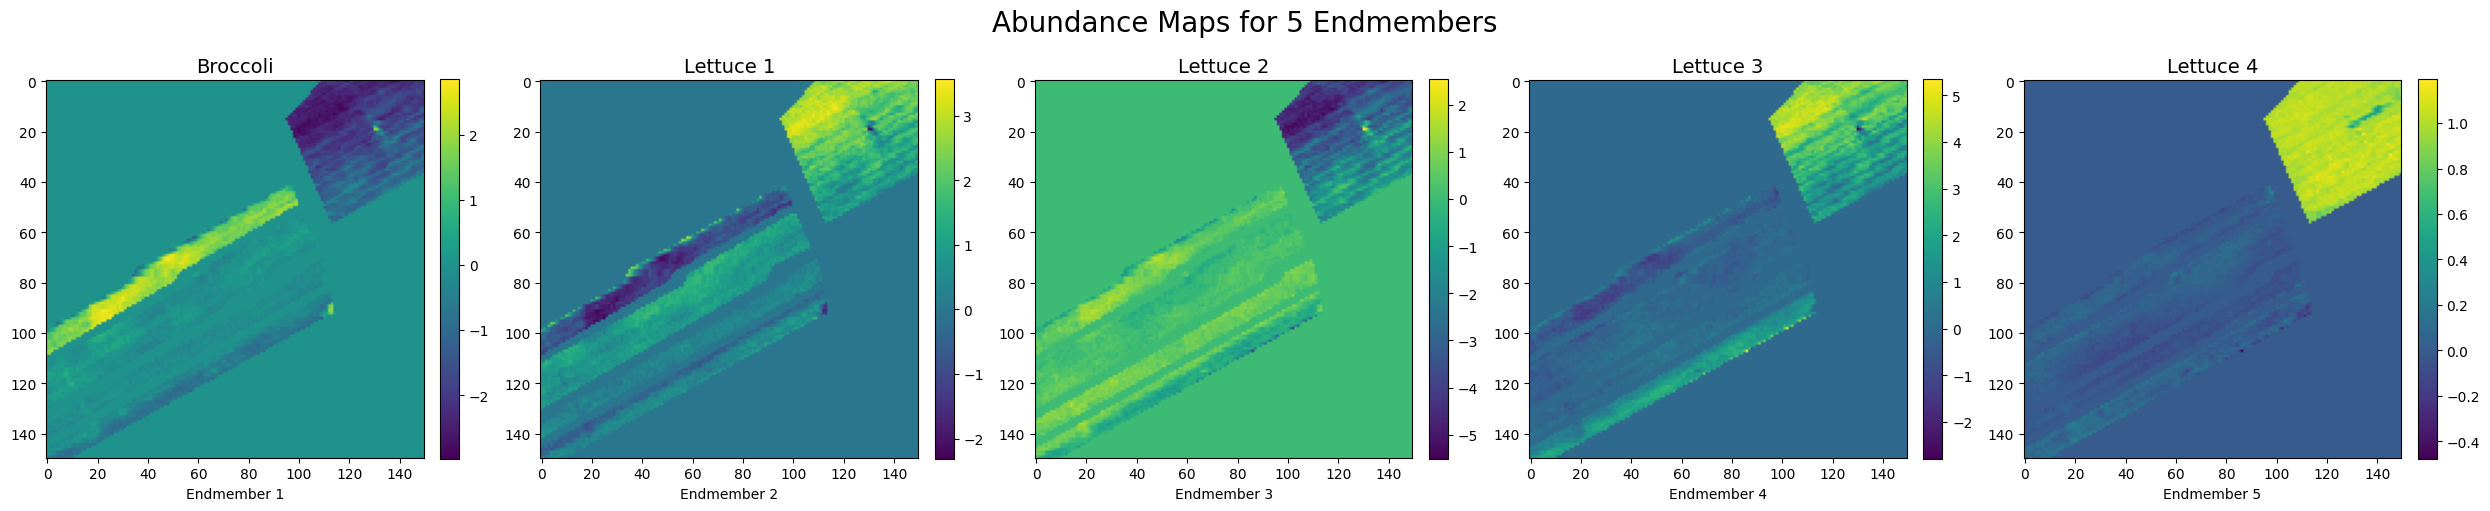

In [100]:
# Initialize abundance tensor (150x150 pixels, 5 endmembers)
theta_ls = np.zeros((150, 150, 5))


# Iterate through the label map and apply LS only to valid pixels
for i in range(labels.shape[0]):
    for j in range(labels.shape[1]):

        # Only process pixels with non-zero labels
        if labels[i, j] != 0:

            # Extract spectral signature of the pixel
            pixel_spectrum = y[i, j, :].reshape(-1, 1)

            # Estimate abundance vector
            theta_ls[i, j, :] = compute_ls_solution(X, pixel_spectrum)


print("--- Results for 1(a): Least Squares ---")

compare_tables(labels, theta_ls)
r_error(theta_ls)
plot_endmembers(theta_ls)

### (b) Least squares imposing the sum-to-one constraint

In [101]:
# Function that computes the Least Squares solution with the sum-to-one constraint
def compute_ls_sum_to_one(X, y_pixel):
    """
    Compute the abundance vector using Least Squares
    while enforcing the sum-to-one constraint.
    """

    # Step 1: compute the unconstrained LS solution
    theta_ls = compute_ls_solution(X, y_pixel)

    # Create a vector of ones (size = number of endmembers)
    ones_vec = np.ones(X.shape[1])

    # Compute (X^T X)^(-1)
    XtX_inv = np.linalg.inv(X.T @ X)

    # Numerator of the Lagrange multiplier
    lambda_num = 1 - np.dot(ones_vec.T, theta_ls)

    # Denominator of the Lagrange multiplier
    lambda_den = ones_vec.T @ XtX_inv @ ones_vec

    # Lagrange multiplier
    lambda_val = lambda_num / lambda_den

    # Apply correction to enforce sum(theta) = 1
    theta_corrected = theta_ls + XtX_inv @ (lambda_val * ones_vec)

    return theta_corrected

Processing... (this may take a few seconds)
--- Results for 1(b): Least Squares (Sum-to-One Constraint) ---
Check passed! Non-zero pixels match.
The reconstruction error is: 248397.1714


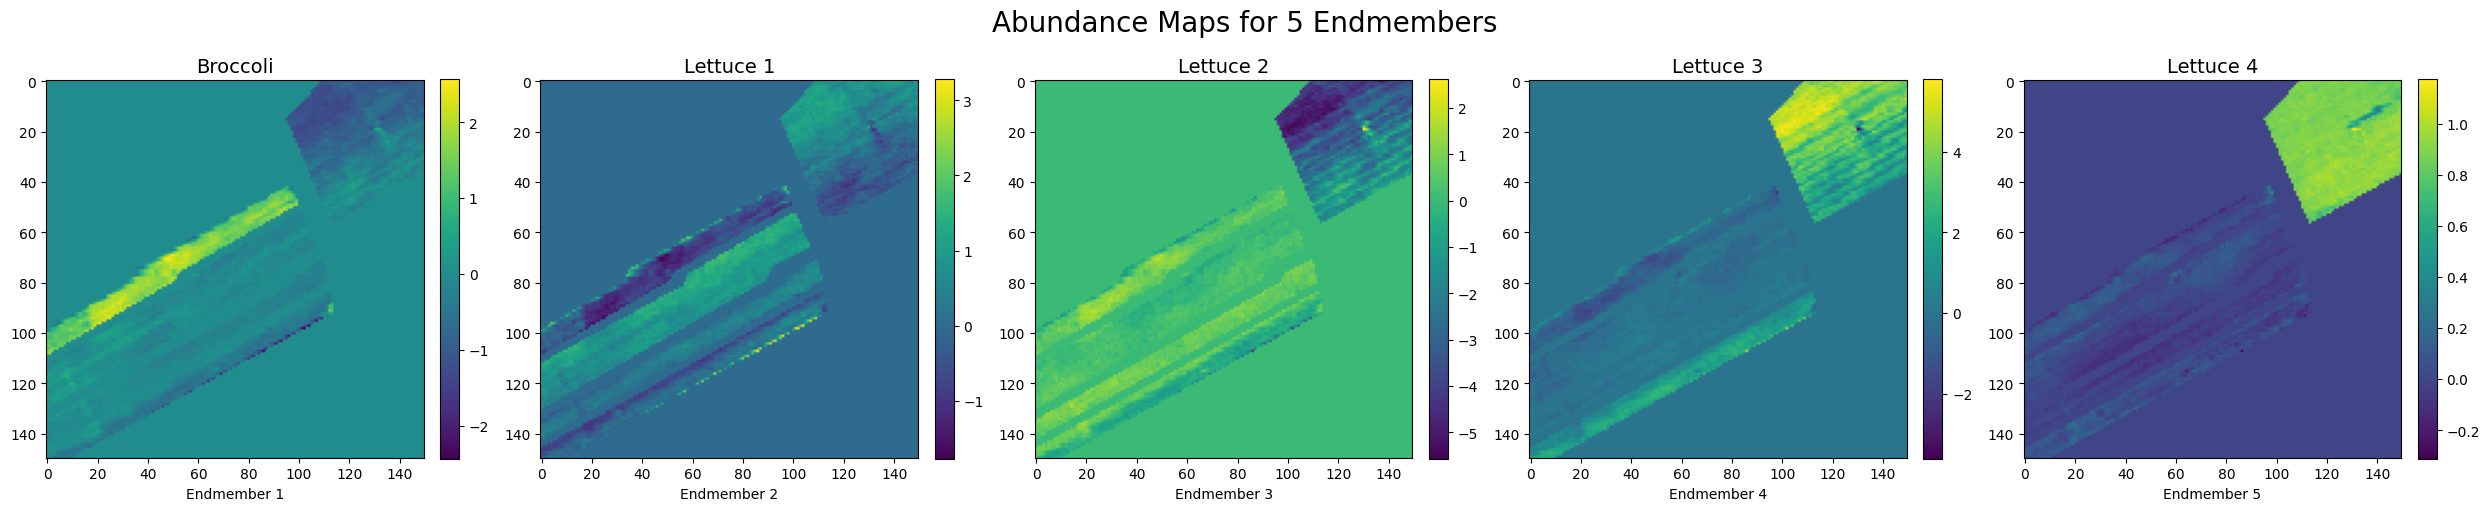

In [102]:
# Initialize abundance tensor
theta_sum_one = np.zeros((150, 150, 5))

print("Processing... (this may take a few seconds)")


# Iterate through the label map
for i in range(labels.shape[0]):
    for j in range(labels.shape[1]):

        # Only compute abundances for valid pixels
        if labels[i, j] != 0:

            pixel_spectrum = y[i, j, :].reshape(-1, 1)

            theta_sum_one[i, j, :] = compute_ls_sum_to_one(X, pixel_spectrum)


print("--- Results for 1(b): Least Squares (Sum-to-One Constraint) ---")

compare_tables(labels, theta_sum_one)
r_error(theta_sum_one)
plot_endmembers(theta_sum_one)

### (c) Least squares imposing the non-negativity constraint on the entries of θ 

Running NNLS estimation... (this may take a few seconds)
--- Results for 1(c): Non-Negative Least Squares (NNLS) ---
Check passed! Non-zero pixels match.
The reconstruction error is: 1320048.3506


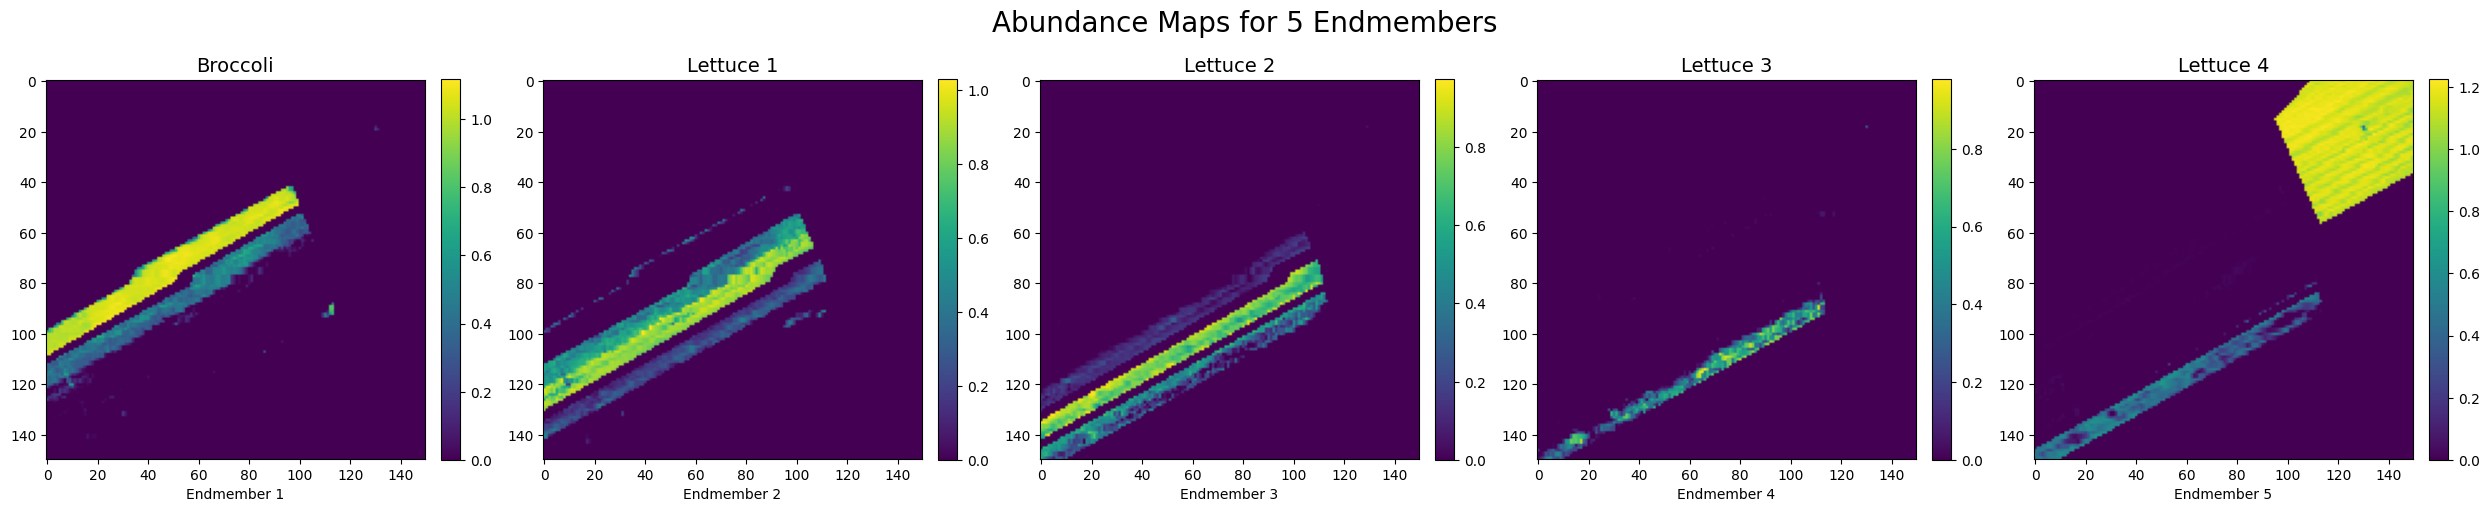

In [103]:
# Initialize abundance tensor for NNLS results
theta_nnls = np.zeros((150, 150, 5))

print("Running NNLS estimation... (this may take a few seconds)")


# Iterate through all pixels and compute abundances for valid ones
for i in range(labels.shape[0]):
    for j in range(labels.shape[1]):

        # Process only pixels with non-zero class labels
        if labels[i, j] != 0:

            # Extract pixel spectral signature (1D array required by nnls)
            pixel_spectrum = y[i, j, :]

            # Solve the Non-Negative Least Squares problem
            theta_est, _ = opt.nnls(X, pixel_spectrum)

            # Store estimated abundances
            theta_nnls[i, j, :] = theta_est


print("--- Results for 1(c): Non-Negative Least Squares (NNLS) ---")

compare_tables(labels, theta_nnls)
r_error(theta_nnls)
plot_endmembers(theta_nnls)

### (d) Least squares imposing both the non-negativity and the sum-to-one constraint on the entries of θ. 

Running Fully Constrained Least Squares (FCLS)...
--- Results for 1(d): Fully Constrained Least Squares (FCLS) ---
Check passed! Non-zero pixels match.
The reconstruction error is: 7119900.0012


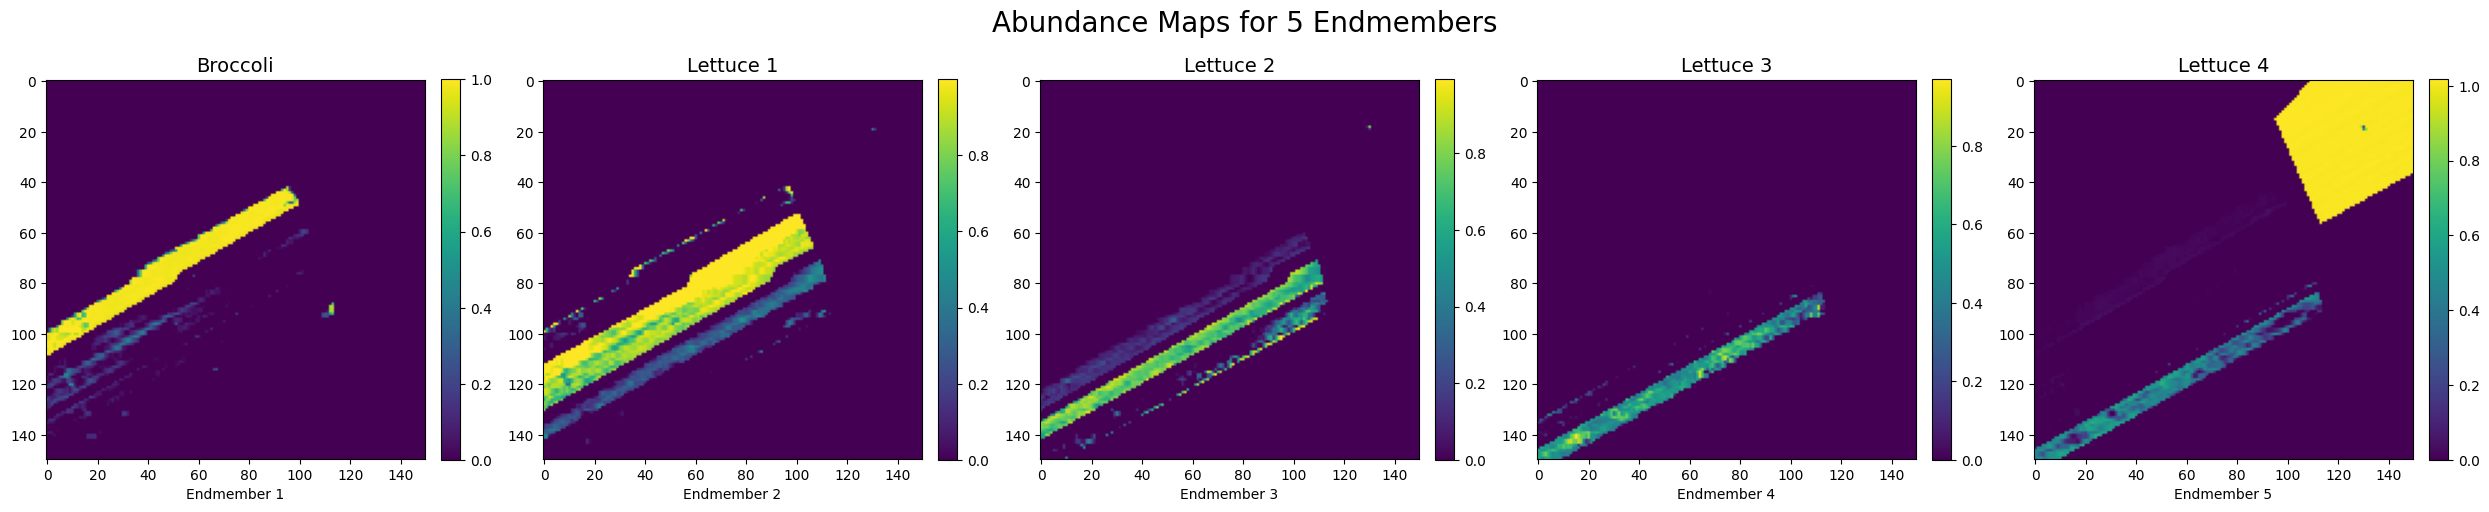

In [104]:
# Initialize abundance tensor for the FCLS solution
theta_fcls = np.zeros((150, 150, 5))

# Large weight used to strongly enforce the sum-to-one constraint
constraint_weight = 1e5


# Step 1: Augment the endmember matrix
# Original X size: 204 x 5
# After augmentation: 205 x 5
ones_vector = np.ones((1, X.shape[1])) * constraint_weight
X_extended = np.vstack((X, ones_vector))

print("Running Fully Constrained Least Squares (FCLS)...")


# Step 2: Process each pixel
for i in range(labels.shape[0]):
    for j in range(labels.shape[1]):

        # Only process pixels with valid labels
        if labels[i, j] != 0:

            # Extract pixel spectral signature
            pixel_spectrum = y[i, j, :]

            # Augment the observation vector (size becomes 205)
            y_extended = np.append(pixel_spectrum, constraint_weight)

            # Solve using NNLS
            theta_est, _ = opt.nnls(X_extended, y_extended)

            # Store abundance vector
            theta_fcls[i, j, :] = theta_est


print("--- Results for 1(d): Fully Constrained Least Squares (FCLS) ---")

compare_tables(labels, theta_fcls)
r_error(theta_fcls)
plot_endmembers(theta_fcls)

### (e) LASSO

Running LASSO estimation (progress indicator below): .............................
--- Results for 1(e): LASSO (Sparsity via L1 Regularization) ---
Check passed! Non-zero pixels match.
The reconstruction error is: 439899.7802


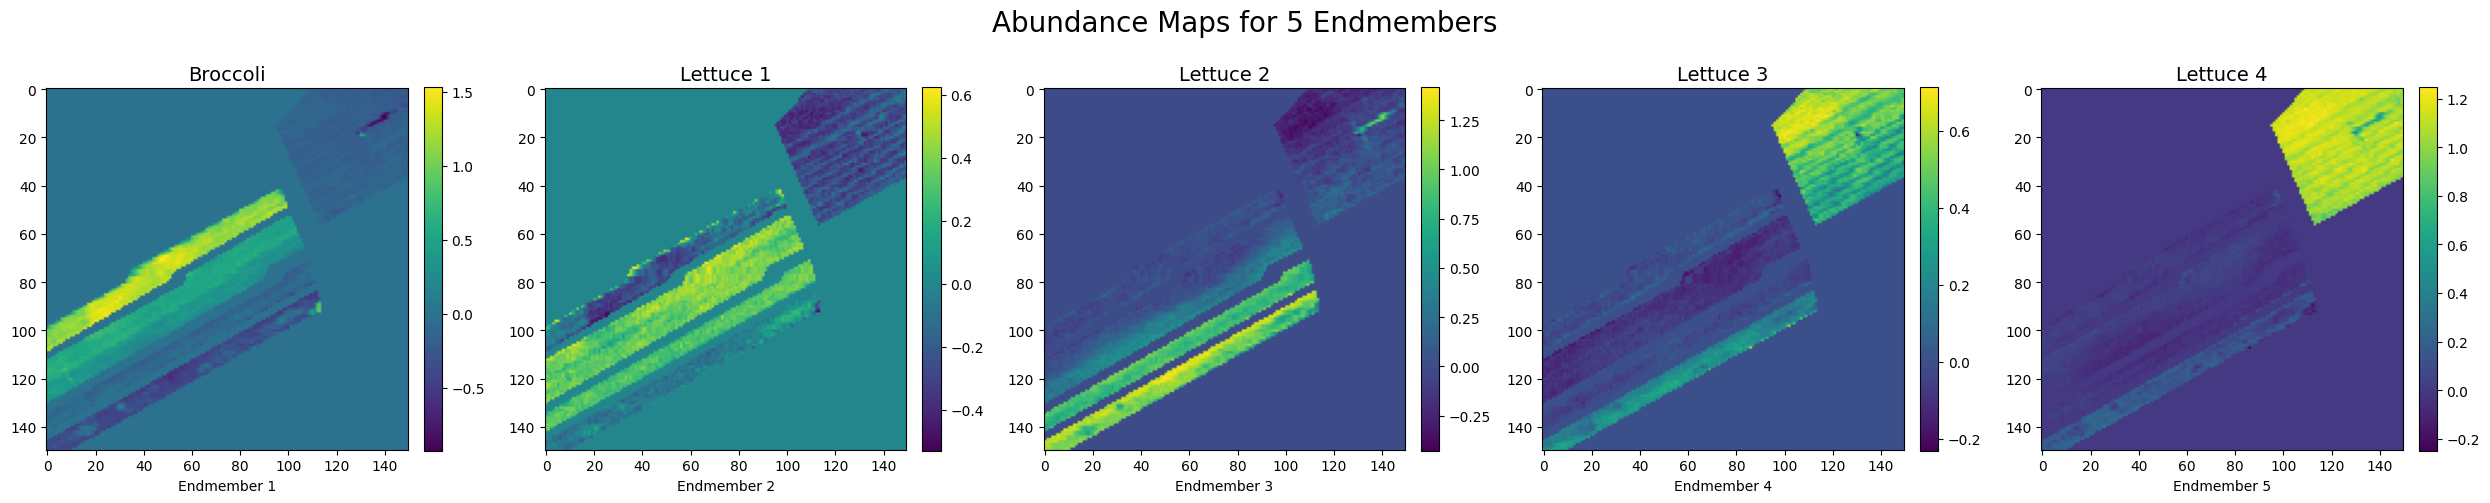

In [105]:
# Suppress convergence warnings from the LASSO solver
warnings.filterwarnings("ignore", category=ConvergenceWarning)


# Initialize abundance tensor for LASSO results
theta_lasso = np.zeros((150, 150, 5))

print("Running LASSO estimation (progress indicator below): ", end="")


# Initialize LASSO regression model
lasso_model = linear_model.Lasso()


# Iterate through the image pixels
for i in range(labels.shape[0]):

    for j in range(labels.shape[1]):

        # Only process pixels with valid labels
        if labels[i, j] != 0:

            # Extract spectral signature of the pixel
            pixel_spectrum = y[i, j, :].reshape(-1, 1)

            # Fit LASSO model
            lasso_model.fit(X, pixel_spectrum)

            # Store estimated coefficients (abundances)
            theta_lasso[i, j, :] = lasso_model.coef_

    # Print simple progress indicator every 5 rows
    if i % 5 == 0 and i != 0:
        print(".", end="")


print("\n--- Results for 1(e): LASSO (Sparsity via L1 Regularization) ---")

compare_tables(labels, theta_lasso)
r_error(theta_lasso)
plot_endmembers(theta_lasso)

## 1.B Compare the results obtained from the above five methods

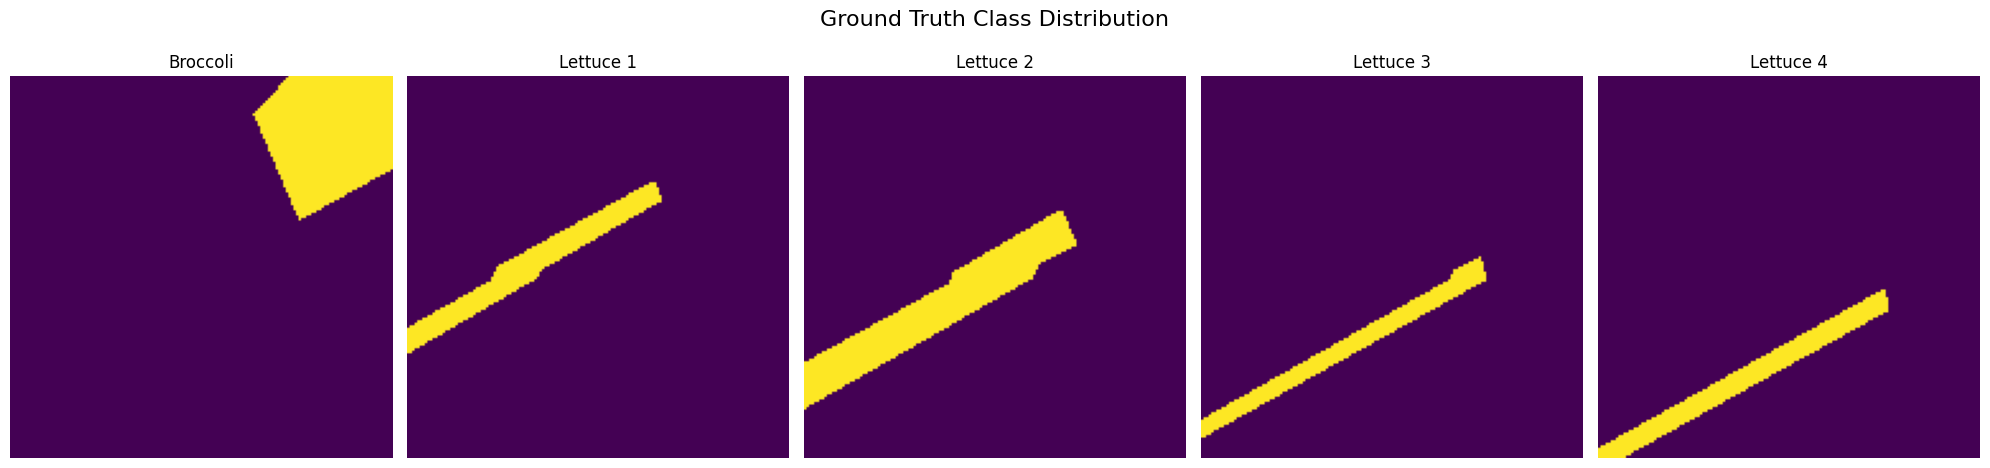

In [106]:
def show_ground_truth_classes(label_map):
    """
    Visualize the spatial location of each class
    using the ground truth labels.
    """

    material_names = ['Broccoli', 'Lettuce 1', 'Lettuce 2', 'Lettuce 3', 'Lettuce 4']

    fig, axes = plt.subplots(1, 5, figsize=(20,5))

    for idx in range(5):

        # Create binary mask for each material
        mask = np.where(label_map == idx+1, 1, 0)

        ax = axes[idx]
        ax.imshow(mask, cmap='viridis')
        ax.set_title(material_names[idx])
        ax.axis('off')

    fig.suptitle("Ground Truth Class Distribution", fontsize=16)

    plt.tight_layout()
    plt.show()


show_ground_truth_classes(labels)

### Method Comparison

In order to evaluate the performance of the spectral unmixing methods, we compare the resulting abundance maps with the ground truth class masks.

By examining the spatial distribution of the abundance maps, we observe that the estimated abundances generally correspond to the regions where the respective materials appear in the ground truth labels. This indicates that the unmixing process is able to capture the dominant materials in each pixel.

The constrained methods, such as NNLS and Fully Constrained Least Squares (FCLS), produce abundance maps that are more physically meaningful because they enforce non-negativity and, in the case of FCLS, the sum-to-one constraint. These constraints ensure that the abundance values represent valid material proportions.

In contrast, the unconstrained Least Squares method may generate negative abundance values, which are not physically interpretable, even though it often achieves a lower reconstruction error.

### Reconstruction Error

The reconstruction error measures how well each method can approximate the original spectral signature of the pixels.

| Method | Reconstruction Error |
|------|------|
| Least Squares | 164596 |
| LS + Sum-to-One | 248397 |
| NNLS | 1320048 |
| FCLS | 7119900 |
| LASSO | 439899 |

The unconstrained Least Squares method produces the lowest reconstruction error because it has the greatest flexibility when fitting the data. However, this flexibility may lead to unrealistic abundance values.

When constraints are introduced, such as non-negativity or sum-to-one, the solution space becomes more restricted. As a result, the reconstruction error increases. Despite this increase, the constrained methods produce abundance estimates that are more consistent with the physical interpretation of the problem.

The LASSO method encourages sparse abundance vectors, meaning that only a small number of endmembers contribute significantly to each pixel. This may improve interpretability but can also increase the reconstruction error compared to unconstrained solutions.

# Part 2 (classification) 

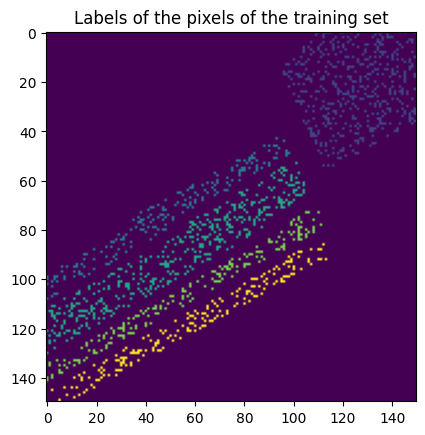

In [107]:

# Trainining set for classification 
Salinas_labels = sio.loadmat('classification_labels.mat')
Training_Set = (np.reshape(Salinas_labels['Training_Set'],(150,150))).T
Test_Set = (np.reshape(Salinas_labels['Test_Set'],(150,150))).T
Operational_Set = (np.reshape(Salinas_labels['Operational_Set'],(150,150))).T

fig = plt.figure()
plt.imshow(Training_Set)
plt.title('Labels of the pixels of the training set')
plt.show()

### Construction of Classification Datasets

For the classification task, the hyperspectral cube must be transformed into a dataset suitable for machine learning algorithms.

Each pixel with a non-zero class label is converted into a sample where:

- the **204 spectral bands** represent the feature vector
- the **class label** represents the target value

Thus, each sample contains **204 features and 1 label**, resulting in a dataset with **205 columns**.

Three datasets are created using the provided label masks:

- **Training set** – used to train the classifiers  
- **Test set** – used to evaluate the classifiers  
- **Operational set** – used for classification after training

In [108]:
def build_classification_dataset(label_map):
    """
    Create a dataset for classification from a label map.

    Parameters
    ----------
    label_map : 150x150 matrix containing class labels

    Returns
    -------
    dataset : matrix where
              columns 0–203 → spectral features
              column 204 → class label
    """

    # Initialize dataset with a dummy row (204 features + 1 label)
    dataset = np.zeros((1, 205))

    rows, cols = label_map.shape

    for i in range(rows):
        for j in range(cols):

            label_value = label_map[i, j]

            # Only consider pixels with non-zero labels
            if label_value != 0:

                # Extract spectral signature (204 bands)
                spectral_vector = HSI[i, j, :].flatten()

                # Combine spectral data with class label
                sample = np.concatenate((spectral_vector, [label_value]))

                # Append sample to dataset
                dataset = np.vstack((dataset, sample))

    # Remove the initial dummy row
    return dataset[1:]

### Feature and Label Separation

After constructing the datasets, the spectral features and the corresponding class labels are separated.

- **X** contains the spectral features (204 bands)  
- **y** contains the class labels (material categories)

This separation is required by most machine learning algorithms, which expect the input features and target labels as separate variables.

In [109]:
training_dataset = build_classification_dataset(Training_Set)
test_dataset = build_classification_dataset(Test_Set)
operational_dataset = build_classification_dataset(Operational_Set)


# Separate features and labels
X_train, y_train = training_dataset[:, :-1], training_dataset[:, -1]
X_test, y_test = test_dataset[:, :-1], test_dataset[:, -1]
X_operational, y_operational = operational_dataset[:, :-1], operational_dataset[:, -1]

### Confusion Matrix Visualization

To evaluate the performance of the classifiers, a confusion matrix is used.

The confusion matrix compares the **true class labels** with the **predicted labels** produced by the classifier.

A normalized confusion matrix is displayed, where each row represents the distribution of predicted labels for a given true class. Ideally, most of the values should appear along the diagonal, indicating correct classifications.

In addition to the confusion matrix, the overall classification **accuracy (success rate)** is also reported.

In [110]:
def display_confusion_matrix(model, X_data, y_true):
    """
    Display accuracy and normalized confusion matrix for a classifier.
    """

    # Predictions
    predictions = model.predict(X_data)

    # Compute accuracy
    acc = accuracy_score(y_true, predictions)
    print(f"Accuracy: {acc*100:.2f}%\n")

    # Compute normalized confusion matrix
    cm = confusion_matrix(y_true, predictions, normalize='true')

    # Unique class labels
    class_labels = np.unique(y_true).astype(int)

    # Plot heatmap
    plt.figure(figsize=(8,6))
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt=".2%",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cmap="Blues",
        cbar=True
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")

    plt.show()

### Naïve Bayes Classifier – Cross Validation

To evaluate the performance of the Naïve Bayes classifier, we perform 10-fold cross validation on the training set.

In each iteration, the training set is divided into 10 subsets. The classifier is trained on 9 subsets and evaluated on the remaining subset. This process is repeated ten times, and the classification error is computed for each iteration.

The final reported values correspond to the mean classification error and the standard deviation across the 10 folds.

In [111]:
# Initialize the Naive Bayes classifier
nb_model = GaussianNB()

print("Running 10-fold cross validation on the training set...")

# Perform 10-fold cross validation
# cross_val_score returns accuracy values
cv_scores = cross_val_score(nb_model, X_train, y_train, cv=10)

# Convert accuracy to classification error
nb_errors = 1 - cv_scores

print("\n--- Naïve Bayes Results (Training Set) ---")
print(f"Mean Error: {nb_errors.mean()*100:.2f}%")
print(f"Error Standard Deviation: {nb_errors.std()*100:.2f}%")

Running 10-fold cross validation on the training set...

--- Naïve Bayes Results (Training Set) ---
Mean Error: 1.80%
Error Standard Deviation: 1.39%


In [112]:
class MinimumDistanceClassifier(BaseEstimator):

    def __init__(self, metric='euclidean'):
        self.metric = metric
        self.classes_ = None
        self.centroids_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.centroids_ = np.zeros((len(self.classes_), X.shape[1]))

        for idx, c in enumerate(self.classes_):
            gm = GaussianMixture(n_components=1, random_state=0)
            gm.fit(X[y == c])
            self.centroids_[idx] = gm.means_[0]

        return self

    def predict(self, X):
        distances = cdist(X, self.centroids_, metric=self.metric)
        nearest = np.argmin(distances, axis=1)
        return np.array([self.classes_[i] for i in nearest])

    def score(self, X, y):
        preds = self.predict(X)
        return accuracy_score(y, preds)

### Minimum Euclidean Distance Classifier

The Minimum Distance classifier assigns each pixel to the class whose centroid is closest in terms of Euclidean distance.

During training, the centroid (mean spectral signature) of each class is estimated using the training samples. In the prediction stage, each pixel is assigned to the class with the smallest distance to its centroid.

To evaluate the performance of this classifier, 10-fold cross validation is applied to the training set and the mean classification error and standard deviation are reported.

In [113]:
print("Running 10-fold cross validation for Minimum Distance classifier...")

md_classifier = MinimumDistanceClassifier()

cv_scores = cross_val_score(md_classifier, X_train, y_train, cv=10)

md_errors = 1 - cv_scores

print("\n--- Minimum Euclidean Distance Results (Training Set) ---")
print(f"Mean Error: {md_errors.mean()*100:.2f}%")
print(f"Error Standard Deviation: {md_errors.std()*100:.2f}%")

Running 10-fold cross validation for Minimum Distance classifier...

--- Minimum Euclidean Distance Results (Training Set) ---
Mean Error: 2.84%
Error Standard Deviation: 2.23%


### k-Nearest Neighbors Classifier

The k-Nearest Neighbors (k-NN) classifier assigns each pixel to the class that is most common among its k closest neighbors in the feature space.

In this implementation, k is set to 3, meaning that the three nearest training samples are considered when classifying a pixel.

To evaluate the performance of the classifier, 10-fold cross validation is applied to the training set. The mean classification error and the standard deviation across the folds are reported.

In [114]:
# Initialize the k-Nearest Neighbors classifier
knn_model = KNeighborsClassifier(n_neighbors=3)

print("Running 10-fold cross validation for the k-NN classifier... (this may take a few seconds)")

# Perform 10-fold cross validation on the training set
cv_scores = cross_val_score(knn_model, X_train, y_train, cv=10)

# Convert accuracy scores to classification error
knn_errors = 1 - cv_scores

print("\n--- k-Nearest Neighbors Results (k = 3) ---")
print(f"Mean Error: {knn_errors.mean()*100:.2f}%")
print(f"Error Standard Deviation: {knn_errors.std()*100:.2f}%")

Running 10-fold cross validation for the k-NN classifier... (this may take a few seconds)

--- k-Nearest Neighbors Results (k = 3) ---
Mean Error: 1.04%
Error Standard Deviation: 0.83%


### Bayesian Classifier (LDA)

The Bayesian classifier assumes that the feature vectors of each class follow a multivariate normal distribution. In this implementation, Linear Discriminant Analysis (LDA) is used to model the class distributions.

To improve the stability of the covariance estimation, the eigen solver with automatic shrinkage is used.

The classifier is evaluated using 10-fold cross validation on the training set, and the mean classification error and standard deviation across the folds are reported.

In [115]:
# Suppress warning messages during execution
warnings.filterwarnings("ignore")

# Initialize the Bayesian classifier using Linear Discriminant Analysis
# The eigen solver with shrinkage helps stabilize covariance estimation
lda_model = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')

print("Running 10-fold cross validation for the Bayesian classifier...")

# Perform 10-fold cross validation on the training set
cv_scores = cross_val_score(lda_model, X_train, y_train, cv=10)

# Convert accuracy scores to classification error
lda_errors = 1 - cv_scores

print("\n--- Bayesian Classifier Results (Training Set) ---")
print(f"Mean Error: {lda_errors.mean()*100:.2f}%")
print(f"Error Standard Deviation: {lda_errors.std()*100:.2f}%")

Running 10-fold cross validation for the Bayesian classifier...

--- Bayesian Classifier Results (Training Set) ---
Mean Error: 1.32%
Error Standard Deviation: 1.00%


### Test Set Evaluation – Naïve Bayes

After cross-validation, the Naïve Bayes classifier is trained using the entire training dataset.  
Its performance is then evaluated on the test set.

The confusion matrix illustrates how many pixels from each class are correctly classified and how many are misclassified. A classifier with good performance will produce a confusion matrix with large values along the diagonal.

--- Test Set Evaluation: Naïve Bayes ---
Accuracy: 98.43%



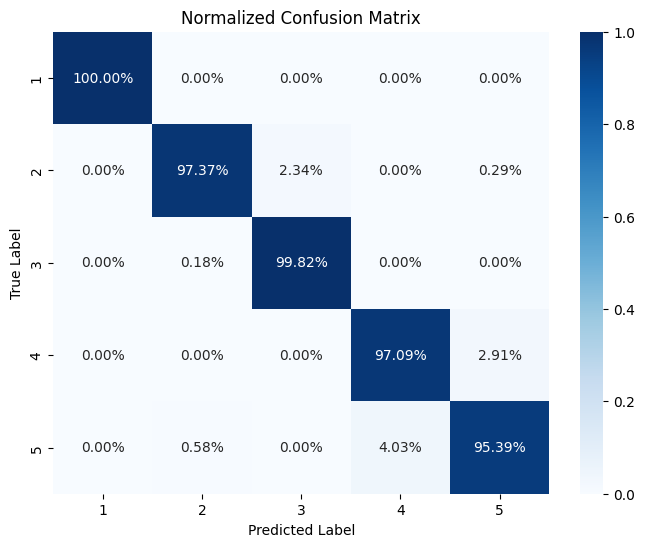

In [116]:
# --- Test Set Evaluation: Naïve Bayes Classifier ---

print("--- Test Set Evaluation: Naïve Bayes ---")

# Train the model using the full training dataset
nb_model.fit(X_train, y_train)

# Evaluate the model on the test set and display the confusion matrix
display_confusion_matrix(nb_model, X_test, y_test)

### Test Set Evaluation – Minimum Euclidean Distance Classifier

The Minimum Euclidean Distance classifier is trained using the full training dataset.  
Each class is represented by its centroid, which corresponds to the mean spectral signature of the class.

During prediction, each pixel is assigned to the class whose centroid has the smallest Euclidean distance from the pixel's spectral signature.

The confusion matrix illustrates the classification performance on the test set.

--- Test Set Evaluation: Minimum Euclidean Distance ---
Accuracy: 97.55%



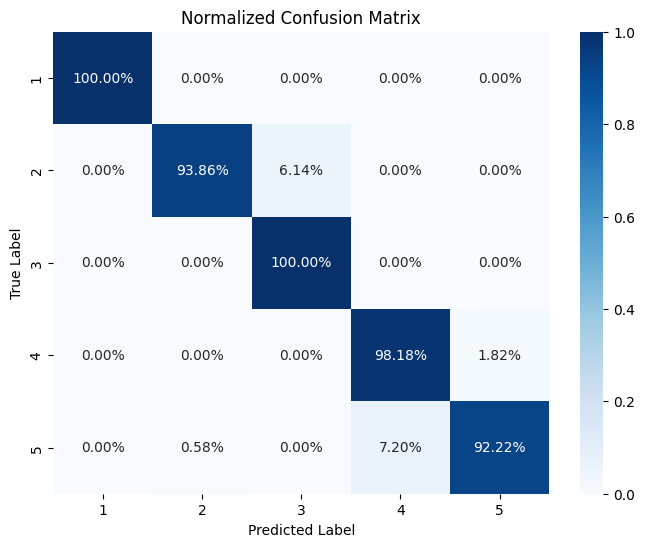

In [117]:
# --- Test Set Evaluation: Minimum Euclidean Distance Classifier ---

print("--- Test Set Evaluation: Minimum Euclidean Distance ---")

# Train the classifier using the full training dataset
md_classifier.fit(X_train, y_train)

# Evaluate the classifier on the test set and display the confusion matrix
display_confusion_matrix(md_classifier, X_test, y_test)

### Test Set Evaluation – k-Nearest Neighbors

The k-Nearest Neighbors classifier is trained using the entire training dataset.  
For each test sample, the classifier computes the Euclidean distance to all training samples and identifies the k closest neighbors.

In this implementation, k = 3 is used. The predicted class corresponds to the majority class among the three nearest neighbors.

The confusion matrix illustrates the classification performance on the test dataset.

--- Test Set Evaluation: k-Nearest Neighbors (k = 3) ---
Accuracy: 98.66%



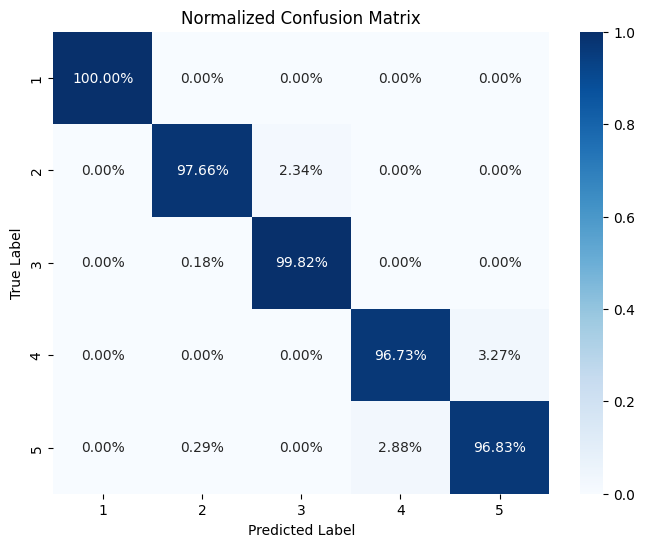

In [118]:
# --- Test Set Evaluation: k-Nearest Neighbors (k = 3) ---

print("--- Test Set Evaluation: k-Nearest Neighbors (k = 3) ---")

# Train the classifier using the full training dataset
knn_model.fit(X_train, y_train)

# Evaluate the classifier on the test set and display the confusion matrix
display_confusion_matrix(knn_model, X_test, y_test)

### Test Set Evaluation – Bayesian Classifier

The Bayesian classifier is implemented using Linear Discriminant Analysis (LDA).  
This method assumes that the feature vectors of each class follow a multivariate normal distribution with class-specific means and a shared covariance matrix.

To improve numerical stability, the eigen solver with shrinkage is used.

The classifier is trained using the entire training dataset and evaluated on the test set using a confusion matrix.

--- Test Set Evaluation: Bayesian Classifier (LDA with shrinkage) ---
Accuracy: 98.52%



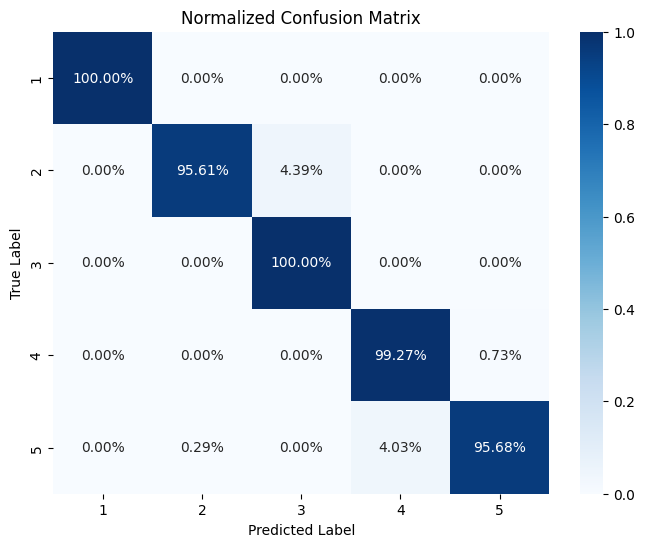

In [119]:
# --- Test Set Evaluation: Bayesian Classifier (LDA with shrinkage) ---

print("--- Test Set Evaluation: Bayesian Classifier (LDA with shrinkage) ---")

# Train the classifier using the full training dataset
lda_model.fit(X_train, y_train)

# Evaluate the classifier on the test set and display the confusion matrix
display_confusion_matrix(lda_model, X_test, y_test)

## 2.B Comparison of the Classification Methods

In this part of the project we evaluated four classifiers using the training and test sets of the hyperspectral dataset. The methods used were:

- Naïve Bayes
- Minimum Euclidean Distance
- k-Nearest Neighbors (k = 3)
- Bayesian classifier using Linear Discriminant Analysis (LDA)

The classification accuracy on the test set is shown below:

| Classifier | Accuracy (%) |
|-------------|--------------|
| Naïve Bayes | 98.43 |
| Minimum Euclidean Distance | 97.55 |
| k-NN (k=3) | 98.66 |
| Bayesian LDA | 98.52 |

All classifiers achieve very high accuracy, showing that the spectral features allow good separation between the classes. The best performance is obtained by the **k-Nearest Neighbors classifier**, followed closely by the **Bayesian LDA** and **Naïve Bayes** classifiers. The **Minimum Euclidean Distance classifier** performs slightly worse than the others.

By examining the confusion matrices, we observe that most predictions lie on the diagonal, indicating correct classification. The main errors occur between **classes 4 and 5**, which suggests that these materials have similar spectral signatures and are therefore more difficult to distinguish.

Overall, the results show that all classifiers perform well on this dataset, with **k-NN providing the highest accuracy**.

## Part 3 – Combination

In this final part, we compare the results obtained from the spectral unmixing methods and the classification methods.

From the abundance maps produced during the spectral unmixing step, we observe that each pixel may contain contributions from multiple endmembers. This means that spectral unmixing provides **fractional information** about the materials present in each pixel.

On the other hand, the classification methods assign **a single class label** to each pixel. This makes classification more suitable for identifying the dominant material in each location.

By comparing the visual results from the abundance maps and the predicted class labels, we observe that the classification results provide a clearer separation between the different materials. In particular, the k-Nearest Neighbors classifier achieves very high accuracy and produces well-separated class regions.

In this dataset, the classification methods appear to perform better than the spectral unmixing methods for identifying the dominant material of each pixel. This is expected because classification directly models the class labels, while spectral unmixing tries to estimate mixture proportions.

Nevertheless, combining information from both approaches can be useful. Spectral unmixing provides additional information about the composition of mixed pixels, while classification provides a clear decision about the most likely material present in each pixel.

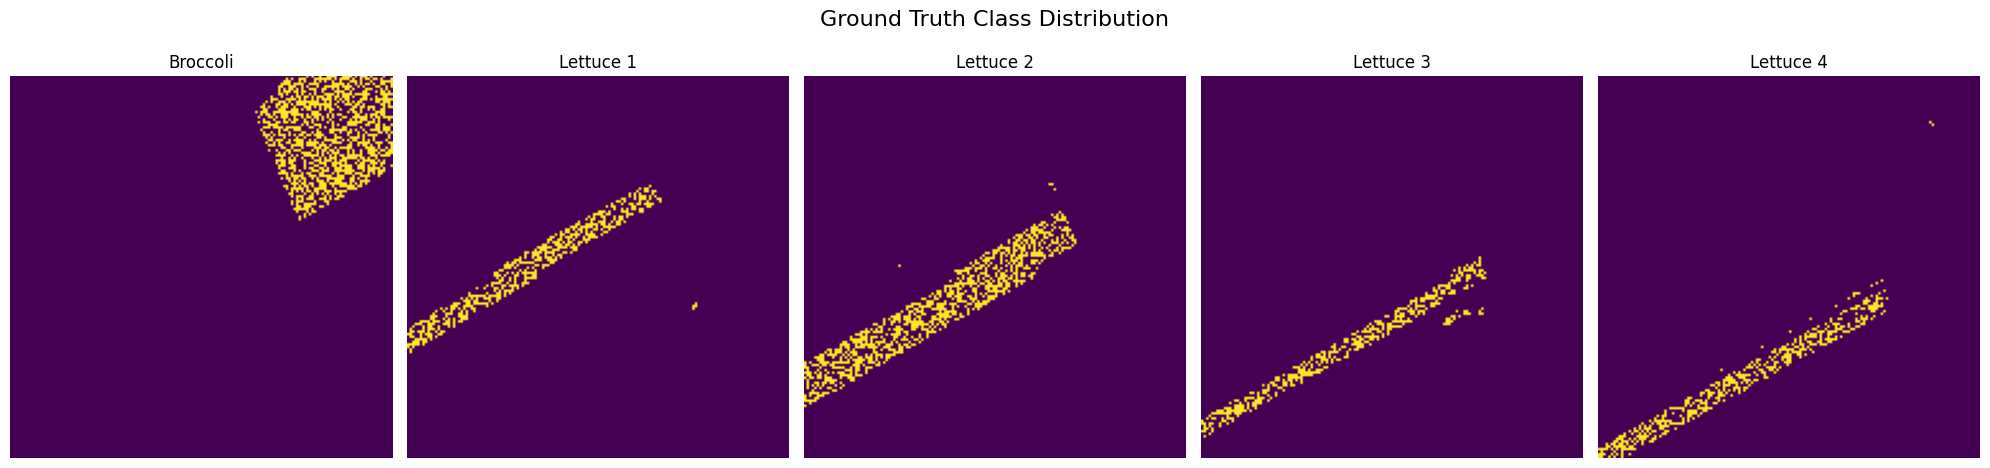

In [120]:
# Predict classes using the best classifier (k-NN)
predicted_labels = knn_model.predict(X_operational)

# Create an empty label image
operational_pred = np.zeros((150,150))

# Iterator through predictions
p_iter = iter(predicted_labels)

for i in range(Operational_Set.shape[0]):
    for j in range(Operational_Set.shape[1]):

        if Operational_Set[i,j] != 0:
            operational_pred[i,j] = next(p_iter)

# Visualize predicted classes
show_ground_truth_classes(operational_pred)

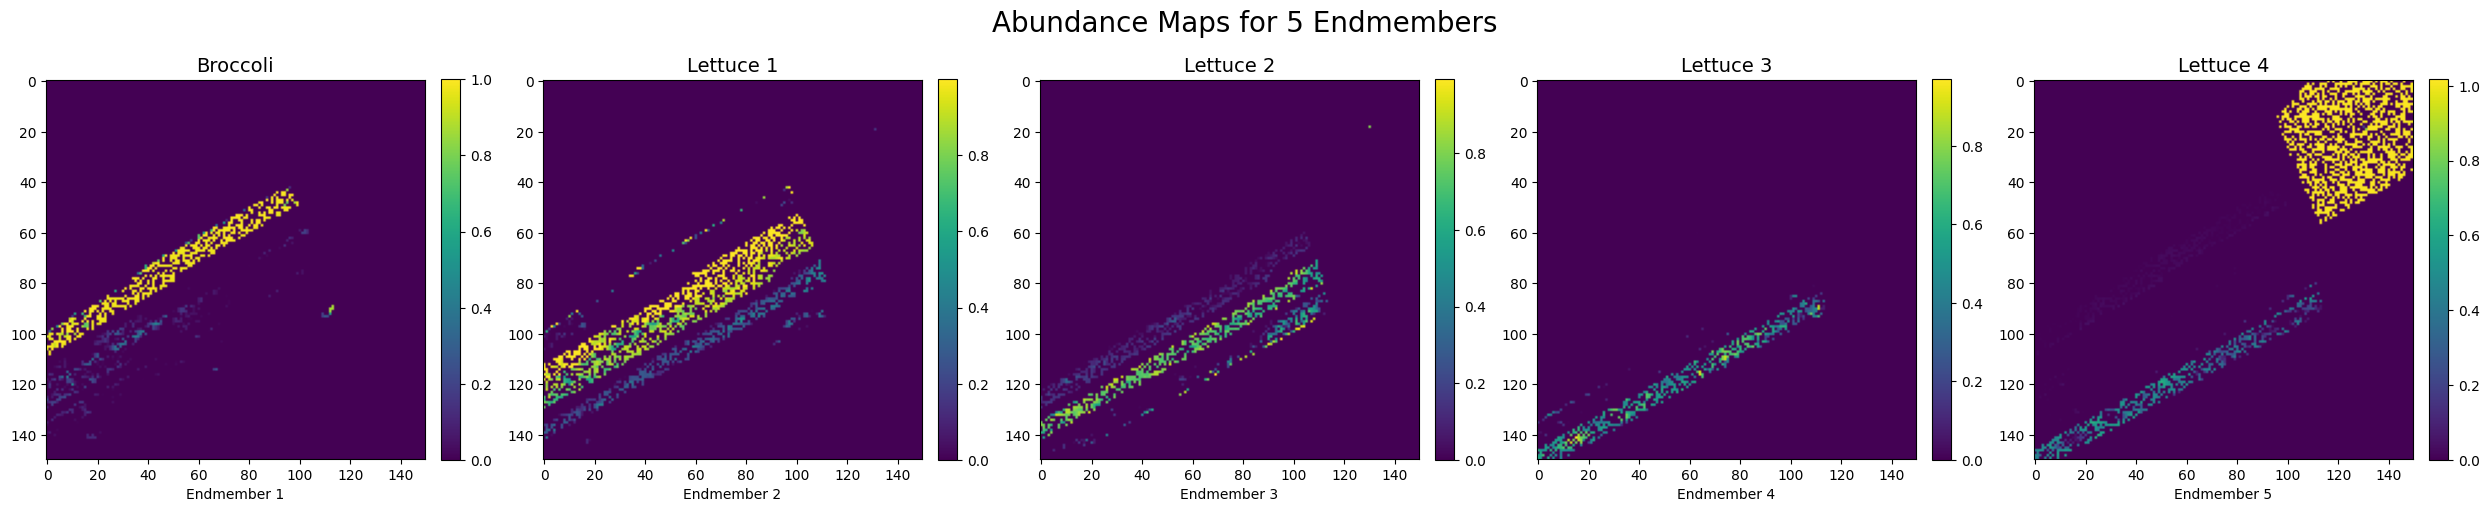

In [121]:
theta_operational = np.zeros((150,150,5))

for i in range(Operational_Set.shape[0]):
    for j in range(Operational_Set.shape[1]):

        if Operational_Set[i,j] != 0:
            pixel = HSI[i,j,:]
            y_aug = np.append(pixel, constraint_weight)

            theta_est,_ = opt.nnls(X_extended, y_aug)

            theta_operational[i,j,:] = theta_est

plot_endmembers(theta_operational)